# Лабораторна робота №1
## Чисельне моделювання 2D рівняння теплопровідност

**Варіант 5**



## 1. Постановка задачі

Чисельно моделюємо двовимірне рівняння теплопровідності з коефіцієнтом **a**, у коді **a = 1**. Область — прямокутник від нуля до **l1** по горизонталі та **l2** по вертикалі; часовий інтервал до **T**. 

Праву частину (джерело) беруть з тестового розв’язку **w**; для цього варіанту вона зникає. Потрібні графіки, похибки та текстовий звіт у PDF.


## 2. Математична модель

Початковий розподіл і значення на межі збігаються з тестовим **w** на відповідних моментах. Сітка рівномірна; якщо область квадратна одиниці, кроки по **x** і **y** в коді однакові (позначення **h**).


In [1]:
# !pip install -q numpy matplotlib sympy plotly

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, display
import sympy as sp
import time
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True


In [ ]:
# --- Параметри задачі (основна частина) ---
a = 1.0          # коефіцієнт у рівнянні (нормований = 1)
l1 = l2 = 1.0    # розміри прямокутника
T_final = 1.0  # кінець часового інтервалу (0,1] — беремо t=1 як кінець

# Варіант 5: Gaussian / фундаментальний розв’язок
A = 1.0
x0, y0 = 0.5, 0.5
t0 = -0.1        # зсув часу, щоб уникнути сингулярності при t=0

# Сітка 
Nx = Ny = 40     # кількість інтервалів => 41 вузол
M = Nx  # для зручності

hx = l1 / Nx
hy = l2 / Ny
assert abs(hx - hy) < 1e-14
h = hx

x = np.linspace(0.0, l1, Nx + 1)
y = np.linspace(0.0, l2, Ny + 1)
X, Y = np.meshgrid(x, y, indexing="ij")

print(f"h = {h:.6g}, Nx=Ny={Nx}, вузлів: {(Nx+1)*(Ny+1)}")


h = 0.025, Nx=Ny=40, вузлів: 1681


## 3. Аналітичний розв’язок (варіант 5)

Гауссівське ядро з умови: максимум біля центру області, з часом поле розмивається. У коді амплітуда **A = 1**, центр у середині квадрата, зсув по часу від’ємний, щоб у початковий момент не було особливості.

Повний запис — у звіті, розділ 3.


In [3]:
def w_exact(x, y, t, a=a, A=A, x0=x0, y0=y0, t0=t0):
    """Точний розв’язок (варіант 5). x,y,t можуть бути масивами (broadcast)."""
    dt = t - t0
    # уникнення ділення на нуль у симуляції
    dt = np.maximum(dt, 1e-15)
    r2 = (x - x0) ** 2 + (y - y0) ** 2
    return (A / dt) * np.exp(-r2 / (4.0 * a * dt))


def laplacian_2d(U, h):
    """5-точковий лапласіан на рівномірній сітці; U shape (Nx+1, Ny+1)."""
    L = np.zeros_like(U)
    L[1:-1, 1:-1] = (
        U[2:, 1:-1] - 2 * U[1:-1, 1:-1] + U[:-2, 1:-1]
    ) / h**2 + (
        U[1:-1, 2:] - 2 * U[1:-1, 1:-1] + U[1:-1, :-2]
    ) / h**2
    return L


def dxx(U, h):
    L = np.zeros_like(U)
    L[1:-1, 1:-1] = (U[2:, 1:-1] - 2 * U[1:-1, 1:-1] + U[:-2, 1:-1]) / h**2
    return L


def dyy(U, h):
    L = np.zeros_like(U)
    L[1:-1, 1:-1] = (U[1:-1, 2:] - 2 * U[1:-1, 1:-1] + U[1:-1, :-2]) / h**2
    return L


## 4. Перевірка правої частини

Праву частину визначають з тестового **w** так, як у книзі: з часової зміни поля віднімають просторовий лапласіан (із коефіцієнтом **a**). Для варіанту 5 при **a = 1** символьна перевірка в комірці з SymPy показує, що джерело тотожно дорівнює нулю.


In [4]:
x_s, y_s, t_s = sp.symbols("x y t", real=True)
a_s, A_s = sp.symbols("a A", positive=True)
x0_s, y0_s, t0_s = sp.symbols("x0 y0 t0", real=True)

dt_s = t_s - t0_s
w_s = (A_s / dt_s) * sp.exp(-((x_s - x0_s) ** 2 + (y_s - y0_s) ** 2) / (4 * a_s * dt_s))

f_s = sp.diff(w_s, t_s) - sp.diff(w_s, x_s, 2) - sp.diff(w_s, y_s, 2)
# У рівнянні коефіцієнт дифузії = 1; у формулі варіанту 5 той самий a=1.
f_s_a1 = sp.simplify(f_s.subs(a_s, 1))
print("f = ∂w/∂t - ∂²w/∂x² - ∂²w/∂y²  (після підстановки a=1) =>", f_s_a1)
if f_s_a1 != 0:
    raise AssertionError("Очікувалось f ≡ 0 при a=1.")
print("SymPy: f ≡ 0 для фундаментального Gaussian-розв’язку при a=1.")


f = ∂w/∂t - ∂²w/∂x² - ∂²w/∂y²  (після підстановки a=1) => 0
SymPy: f ≡ 0 для фундаментального Gaussian-розв’язку при a=1.


## 5. Права частина в коді

Функція **rhs_f** для цього тесту повертає нуль; так зручно, якщо пізніше зміните тест і знадобиться ненульове джерело.


In [5]:
def rhs_f(x, y, t):
    """Права частина рівняння (для варіанту 5 — тотожно 0)."""
    return np.zeros_like(np.broadcast_arrays(x, y, t)[0], dtype=float)


def rhs_f_on_grid(X, Y, t):
    return rhs_f(X, Y, t)


## 6. Чисельні методи

### 6.1 Явна схема
П’ятиточковий лапласіан на площині; крок по часу обраний стійко відносно квадрата просторового кроку (див. Волков [1], схема під номером 6 у джерелі).

### 6.2 Змінні напрямки
Два півкроки по часу; на кожному півкроці прогонка вздовж однієї осі, потім вздовж іншої; значення джерела беруть на середньому шарі за часом [1, с. 237]. У ноутбуці крок по часу узятий рівним просторовому кроку **h**.

### 6.3 ДС за [2]
Таблиця за парністю суми індексів вузла: на півкроці спочатку явне оновлення на одному «кольорі», потім коротке доповнення на іншому без прогонки Томаса. Крок по часу — як у явної схеми.

Подробиці — у звіті, розділ 5.


In [ ]:
def apply_dirichlet(U, t, X, Y):
    """ГУ Діріхле з точного розв’язку на всіх межах."""
    U[0, :] = w_exact(X[0, :], Y[0, :], t)
    U[-1, :] = w_exact(X[-1, :], Y[-1, :], t)
    U[:, 0] = w_exact(X[:, 0], Y[:, 0], t)
    U[:, -1] = w_exact(X[:, -1], Y[:, -1], t)
    return U


def thomas_tridiag_solve(a, b, c, d):
    """Розв’язати T x = d, T — трикутна: b[i]*x[i] + c[i]*x[i+1] + a[i]*x[i-1] = d[i].
    a[0] і c[-1] не використовуються (нульові зв’язки)."""
    n = len(d)
    cp = np.zeros(n)
    dp = np.zeros(n)
    cp[0] = c[0] / b[0]
    dp[0] = d[0] / b[0]
    for i in range(1, n):
        denom = b[i] - a[i] * cp[i - 1]
        if i < n - 1:
            cp[i] = c[i] / denom
        dp[i] = (d[i] - a[i] * dp[i - 1]) / denom
    x = np.zeros(n)
    x[-1] = dp[-1]
    for i in range(n - 2, -1, -1):
        x[i] = dp[i] - cp[i] * x[i + 1]
    return x


def solve_implicit_x(rhs, tau_half, h, X, Y, t_bc):
    """(I - tau_half * dxx) U = rhs; U на межах x та y — з w_exact(t_bc)."""
    r = tau_half / (h * h)
    ni, nj = rhs.shape
    out = np.zeros_like(rhs)
    apply_dirichlet(out, t_bc, X, Y)
    n = ni - 2
    a = np.full(n, -r)
    a[0] = 0.0
    b = np.full(n, 1.0 + 2.0 * r)
    c = np.full(n, -r)
    c[-1] = 0.0
    for j in range(1, nj - 1):
        d_vec = rhs[1:-1, j].copy()
        d_vec[0] += r * out[0, j]
        d_vec[-1] += r * out[-1, j]
        out[1:-1, j] = thomas_tridiag_solve(a, b, c, d_vec)
    apply_dirichlet(out, t_bc, X, Y)
    return out


def solve_implicit_y(rhs, tau_half, h, X, Y, t_bc):
    """(I - tau_half * dyy) U = rhs; межі з w_exact(t_bc)."""
    r = tau_half / (h * h)
    ni, nj = rhs.shape
    out = np.zeros_like(rhs)
    apply_dirichlet(out, t_bc, X, Y)
    n = nj - 2
    a = np.full(n, -r)
    a[0] = 0.0
    b = np.full(n, 1.0 + 2.0 * r)
    c = np.full(n, -r)
    c[-1] = 0.0
    for i in range(1, ni - 1):
        d_vec = rhs[i, 1:-1].copy()
        d_vec[0] += r * out[i, 0]
        d_vec[-1] += r * out[i, -1]
        out[i, 1:-1] = thomas_tridiag_solve(a, b, c, d_vec)
    apply_dirichlet(out, t_bc, X, Y)
    return out


def explicit_step(U, tau, h, t_n, X, Y, f_fn):
    """Один крок явної схеми."""
    Un = U.copy()
    F = f_fn(X, Y, t_n)
    Lap = laplacian_2d(Un, h)
    Un[1:-1, 1:-1] += tau * (Lap[1:-1, 1:-1] + F[1:-1, 1:-1])
    apply_dirichlet(Un, t_n + tau, X, Y)
    return Un


def neighbor_sum_4(U):
    """Сума значень у чотирьох сусідніх вузлах (для внутрішньої області)."""
    S = np.zeros_like(U)
    S[1:-1, 1:-1] = U[:-2, 1:-1] + U[2:, 1:-1] + U[1:-1, :-2] + U[1:-1, 2:]
    return S


def adi_fractional_step(U, tau, h, t_n, X, Y, f_fn):
    """Метод змінних напрямків (дробних шагів) [1, с. 237]; f(t_n+τ/2) на обох півкроках."""
    Un = U.copy()
    t_half = t_n + tau / 2.0
    F_mid = f_fn(X, Y, t_half)
    rhs_star = np.zeros_like(Un)
    rhs_star[1:-1, 1:-1] = (
        Un[1:-1, 1:-1]
        + (tau / 2.0) * dyy(Un, h)[1:-1, 1:-1]
        + (tau / 2.0) * F_mid[1:-1, 1:-1]
    )
    Wstar = solve_implicit_x(rhs_star, tau / 2.0, h, X, Y, t_half)
    rhs_np1 = np.zeros_like(Wstar)
    rhs_np1[1:-1, 1:-1] = (
        Wstar[1:-1, 1:-1]
        + (tau / 2.0) * dxx(Wstar, h)[1:-1, 1:-1]
        + (tau / 2.0) * F_mid[1:-1, 1:-1]
    )
    Un1 = solve_implicit_y(rhs_np1, tau / 2.0, h, X, Y, t_n + tau)
    return Un1


def ds_checkerboard_step(U, tau, h, t_n, X, Y, f_fn):
    """ДС-алгоритм: шахівниця (k+m) mod 2, два півкроки τ/2."""
    dt2 = tau / 2.0
    t_mid = t_n + dt2
    t_np1 = t_n + tau
    ni, nj = U.shape
    h2 = h * h
    coef_imp = 1.0 + tau / h2
    coef_exp = 1.0 - tau / h2
    U0 = U.copy()
    F_n = f_fn(X, Y, t_n)
    F_mid = f_fn(X, Y, t_mid)
    F_np1 = f_fn(X, Y, t_np1)
    W = U0.copy()
    Lap0 = laplacian_2d(U0, h)
    I = np.arange(ni)[:, None]
    J = np.arange(nj)[None, :]
    # Lap0 = laplacian_2d(U0, h)
    interior = (I > 0) & (I < ni - 1) & (J > 0) & (J < nj - 1)
    white = interior & ((I + J) % 2 == 0)
    black = interior & ((I + J) % 2 == 1)
    W[white] = U0[white] + dt2 * (Lap0[white] + F_n[white])

    apply_dirichlet(W, t_mid, X, Y)
    Sc = neighbor_sum_4(W)
    So = neighbor_sum_4(U0)
    rhs_b = coef_exp * U0 + (tau / 4.0) * (Sc + So) / h2 + (tau / 2.0) * F_mid
    # rhs_b = coef_exp * U0 + (tau / 4.0) * (Sc + So) / h2 + (tau / 2.0) * F_mid

    W[black] = rhs_b[black] / coef_imp
    apply_dirichlet(W, t_mid, X, Y)
    U2 = W.copy()
    LapW = laplacian_2d(W, h)
    U2[black] = W[black] + dt2 * (LapW[black] + F_mid[black])

    apply_dirichlet(U2, t_mid, X, Y)
    Sc2 = neighbor_sum_4(U2)
    So2 = neighbor_sum_4(W)
    rhs_w = coef_exp * W + (tau / 4.0) * (Sc2 + So2) / h2 + (tau / 2.0) * F_np1
    U2[white] = rhs_w[white] / coef_imp
    apply_dirichlet(U2, t_np1, X, Y)
    return U2


def run_simulation(method, tau, T_final, X, Y, h, record_every=None):
    """method: 'explicit' | 'adi' | 'symmetric' (остання — ДС [2])"""
    t = 0.0
    U = w_exact(X, Y, t)
    apply_dirichlet(U, t, X, Y)

    history_t = [0.0]
    history_w = [U.copy()]

    f_fn = rhs_f_on_grid
    step_fn = {
        "explicit": explicit_step,
        "adi": adi_fractional_step,
        "symmetric": ds_checkerboard_step,
    }[method]

    nstep = 0
    t0_clock = time.perf_counter()
    while t < T_final - 1e-15:
        tau_eff = min(tau, T_final - t)
        if method == "explicit" and tau_eff < tau:
            # для останнього дрібного кроку перерахунок не потрібен якщо T кратне tau; інакше
            pass
        U = step_fn(U, tau_eff, h, t, X, Y, f_fn)
        t += tau_eff
        nstep += 1
        if record_every is None or nstep % record_every == 0:
            history_t.append(t)
            history_w.append(U.copy())
    elapsed = time.perf_counter() - t0_clock
    return U, np.array(history_t), history_w, nstep, elapsed


In [7]:
# Кроки часу
tau_explicit = 0.2 * h**2 / a
Nt_expl = int(np.ceil(T_final / tau_explicit))
print(f"Явна схема: tau = {tau_explicit:.3e}, орієнтовно {Nt_expl} кроків до t=1")

# ADI: tau = h (клас PR для параболічних задач дозволяє великий крок)
tau_adi = h
Nt_adi = int(np.ceil(T_final / tau_adi))
# ДС [2]: той самий τ, що й для явної (явний півкрок на «білих» вузлах — CFL)
tau_ds = tau_explicit
Nt_ds = int(np.ceil(T_final / tau_ds))
print(f"ADI: tau = {tau_adi:.6g}, кроків ~ {Nt_adi}")
print(f"ДС-алгоритм: tau = {tau_ds:.3e} (як explicit), кроків ~ {Nt_ds}")

# Запис історії рідше для швидкості анімації
record_every_expl = max(1, Nt_expl // 80)
record_every_fast = max(1, Nt_adi // 80)
record_every_ds = max(1, Nt_ds // 80)

print("\nЗапуск explicit...")
W_expl, hist_t_e, hist_w_e, n_e, time_e = run_simulation(
    "explicit", tau_explicit, T_final, X, Y, h, record_every=record_every_expl
)
print(f"  кроків: {n_e}, час: {time_e:.3f} s")

print("Запуск ADI...")
W_adi, hist_t_a, hist_w_a, n_a, time_a = run_simulation(
    "adi", tau_adi, T_final, X, Y, h, record_every=record_every_fast
)
print(f"  кроків: {n_a}, час: {time_a:.3f} s")

print("Запуск ДС-алгоритму...")
W_sym, hist_t_s, hist_w_s, n_s, time_s = run_simulation(
    "symmetric", tau_ds, T_final, X, Y, h, record_every=record_every_ds
)
print(f"  кроків: {n_s}, час: {time_s:.3f} s")


Явна схема: tau = 1.250e-04, орієнтовно 8000 кроків до t=1
ADI: tau = 0.025, кроків ~ 40
ДС-алгоритм: tau = 1.250e-04 (як explicit), кроків ~ 8000

Запуск explicit...
  кроків: 8000, час: 0.243 s
Запуск ADI...
  кроків: 40, час: 0.065 s
Запуск ДС-алгоритму...
  кроків: 8000, час: 1.467 s


## 7. Результати

Теплові карти, тривимірні поверхні та анімація через **FuncAnimation**.


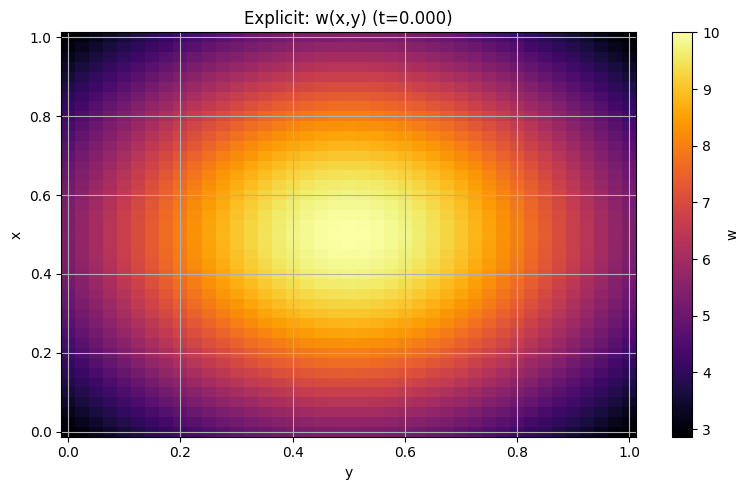

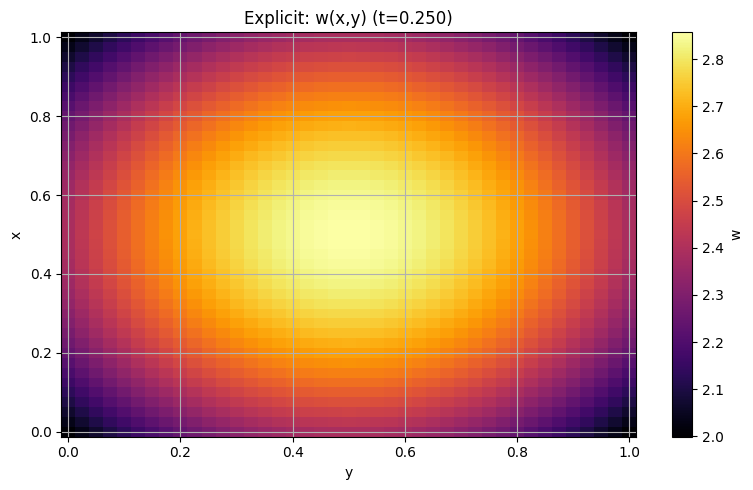

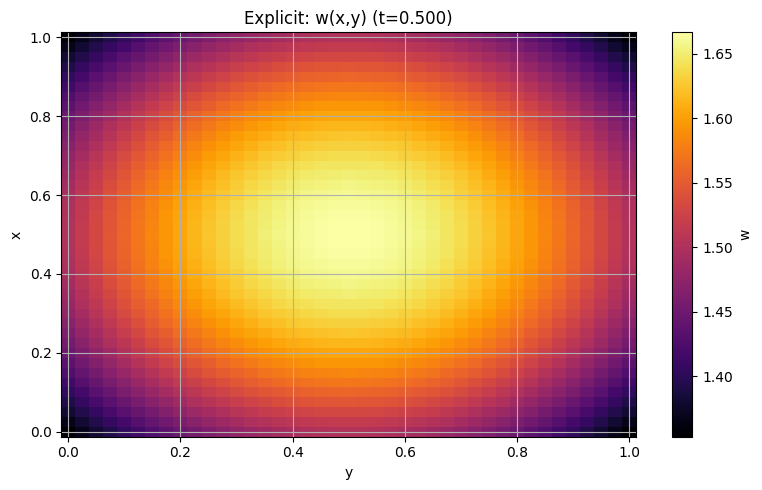

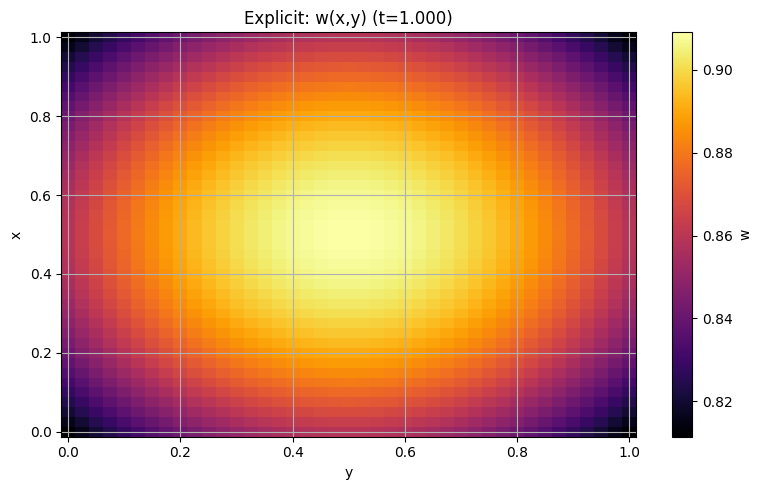

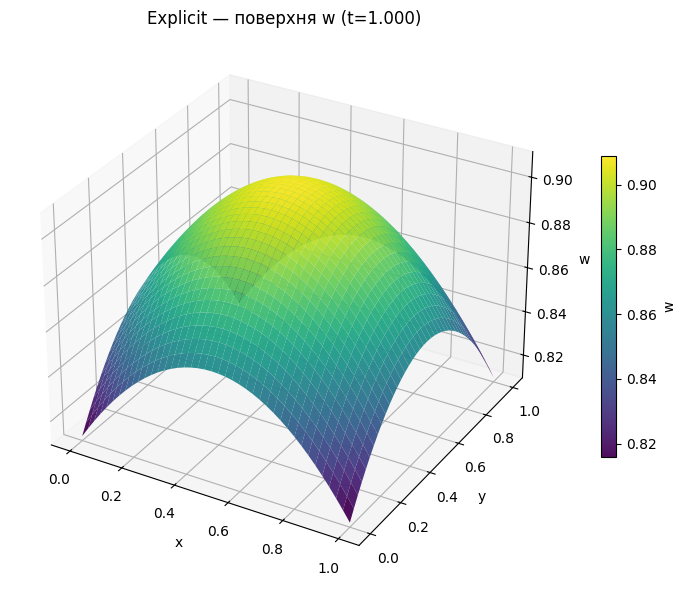

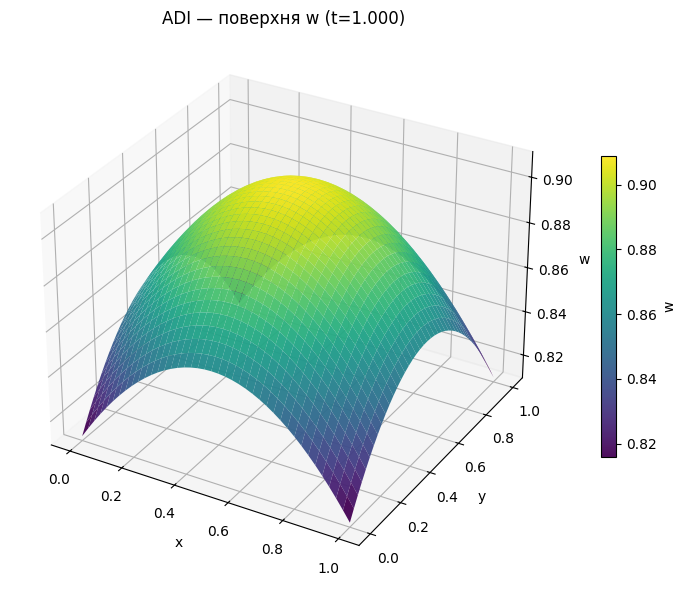

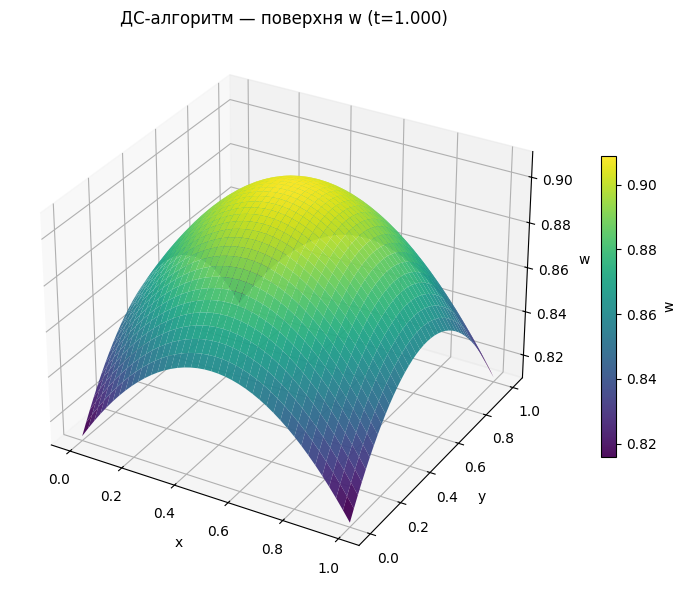

In [8]:
def plot_heatmap(U, title, t_val, vmin=None, vmax=None):
    fig, ax = plt.subplots()
    pcm = ax.pcolormesh(y, x, U.T, shading="auto", cmap="inferno", vmin=vmin, vmax=vmax)
    ax.set_xlabel("y")
    ax.set_ylabel("x")
    ax.set_title(title + f" (t={t_val:.3f})")
    plt.colorbar(pcm, ax=ax, label="w")
    plt.tight_layout()
    plt.show()


def plot_surface_3d(U, title, t_val):
    fig = plt.figure(figsize=(9, 6))
    ax = fig.add_subplot(111, projection="3d")
    surf = ax.plot_surface(X, Y, U, cmap="viridis", edgecolor="none", alpha=0.95)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("w")
    ax.set_title(title + f" (t={t_val:.3f})")
    fig.colorbar(surf, shrink=0.55, label="w")
    plt.tight_layout()
    plt.show()


def error_vs_exact(U, t_val):
    We = w_exact(X, Y, t_val)
    return np.abs(U - We)


# Heatmap для кількох моментів часу (explicit як референс-візуалізація)
for tv in [0.0, 0.25, 0.5, 1.0]:
    if tv == 0.0:
        Ue = w_exact(X, Y, 0.0)
    elif tv <= hist_t_e[-1]:
        idx = np.argmin(np.abs(np.array(hist_t_e) - tv))
        Ue = hist_w_e[idx]
    else:
        Ue = W_expl
    plot_heatmap(Ue, "Explicit: w(x,y)", tv)

# 3D surface у фінальний момент
plot_surface_3d(W_expl, "Explicit — поверхня w", T_final)
plot_surface_3d(W_adi, "ADI — поверхня w", T_final)
plot_surface_3d(W_sym, "ДС-алгоритм — поверхня w", T_final)


In [9]:
def make_animation(history_t, history_w, title_prefix, frame_step=1):
    fig, ax = plt.subplots()
    vmin = float(np.min(history_w[0]))
    vmax = float(np.max(history_w[0]))
    for W in history_w[:: max(1, len(history_w) // 10)]:
        vmin = min(vmin, float(W.min()))
        vmax = max(vmax, float(W.max()))

    pcm = ax.pcolormesh(y, x, history_w[0].T, shading="auto", cmap="inferno", vmin=vmin, vmax=vmax)
    ax.set_xlabel("y")
    ax.set_ylabel("x")
    ttl = ax.set_title(f"{title_prefix}, t={history_t[0]:.4f}")
    plt.colorbar(pcm, ax=ax, label="w")

    def update(frame):
        k = frame * frame_step
        if k >= len(history_w):
            k = len(history_w) - 1
        pcm.set_array(history_w[k].T.ravel())
        ttl.set_text(f"{title_prefix}, t={history_t[k]:.4f}")
        return (pcm, ttl)

    n_frames = max(1, len(history_w) // frame_step)
    anim = animation.FuncAnimation(
        fig, update, frames=n_frames, interval=120, blit=False
    )
    plt.close(fig)
    return anim


anim_e = make_animation(hist_t_e, hist_w_e, "Explicit", frame_step=max(1, len(hist_w_e) // 60))
try:
    display(HTML(anim_e.to_jshtml()))
except Exception as ex:
    print("to_jshtml failed:", ex)
    print("Спробуйте локально зберегти GIF: pip install pillow")


## 8. Аналіз похибки

Точкова різниця між чисельним і тестовим полем у вузлах; у часі — максимум за вузлами та дискретна середньоквадратична міра (узгоджено зі звітом).


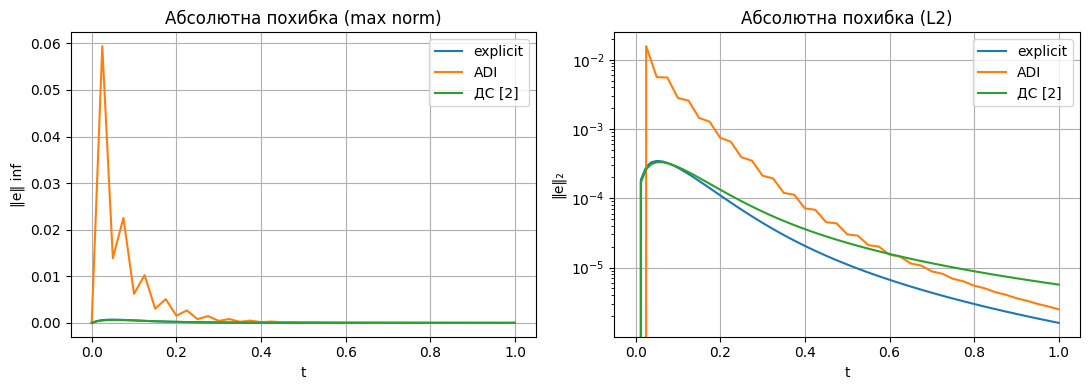

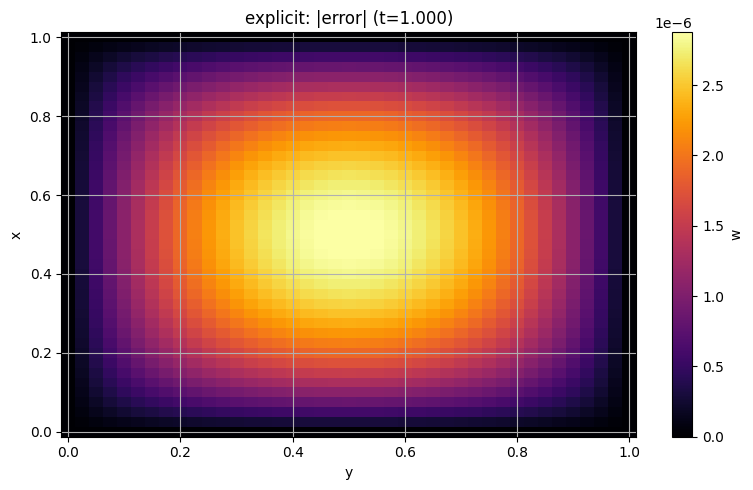

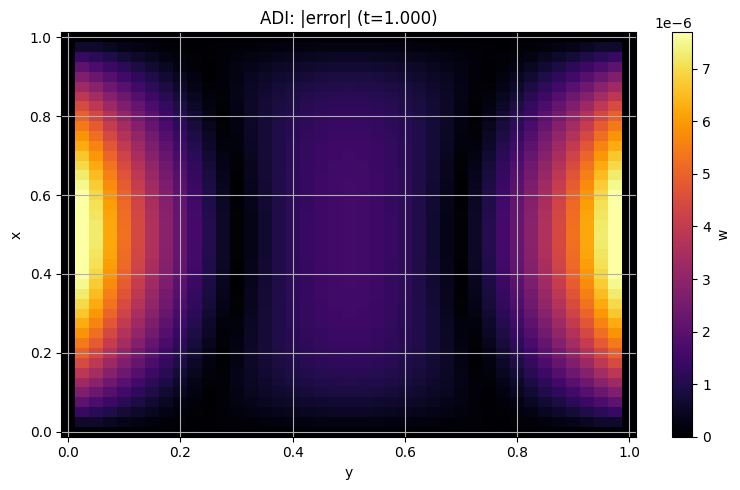

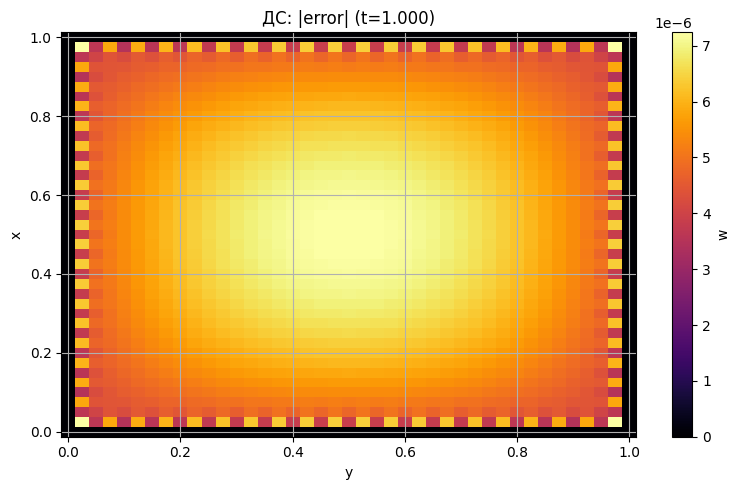

In [17]:
def discrete_l2_norm(E, h):
    """L2 норма на сітці ~ sqrt(h^2 * sum E^2)."""
    return float(np.sqrt(np.sum(E**2) * h * h))


def discrete_linf_norm(E):
    return float(np.max(np.abs(E)))


def error_norms_over_time(history_t, history_w):
    Linf = []
    L2 = []
    for t_k, Wk in zip(history_t, history_w):
        E = np.abs(Wk - w_exact(X, Y, t_k))
        Linf.append(discrete_linf_norm(E))
        L2.append(discrete_l2_norm(E, h))
    return np.array(Linf), np.array(L2)


Le_inf, Le_2 = error_norms_over_time(np.array(hist_t_e), hist_w_e)
La_inf, La_2 = error_norms_over_time(np.array(hist_t_a), hist_w_a)
Ls_inf, Ls_2 = error_norms_over_time(np.array(hist_t_s), hist_w_s)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(hist_t_e, Le_inf, label="explicit")
ax[0].plot(hist_t_a, La_inf, label="ADI")
ax[0].plot(hist_t_s, Ls_inf, label="ДС [2]")
ax[0].set_xlabel("t")
ax[0].set_ylabel("‖e‖ inf")
ax[0].set_title("Абсолютна похибка (max norm)")
ax[0].legend()

ax[1].semilogy(hist_t_e, Le_2, label="explicit")
ax[1].semilogy(hist_t_a, La_2, label="ADI")
ax[1].semilogy(hist_t_s, Ls_2, label="ДС [2]")
ax[1].set_xlabel("t")
ax[1].set_ylabel("‖e‖₂")
ax[1].set_title("Абсолютна похибка (L2)")
ax[1].legend()
plt.tight_layout()
plt.show()

# Heatmap похибки у фінальний час
for name, Wf in [("explicit", W_expl), ("ADI", W_adi), ("ДС", W_sym)]:
    E = error_vs_exact(Wf, T_final)
    plot_heatmap(E, f"{name}: |error|", T_final, vmin=0, vmax=np.percentile(E, 99))


## 9. Порівняння методів

Таблицю та короткий коментар формує наступна комірка після запуску симуляцій.


In [18]:
def final_errors(W, t_val):
    E = np.abs(W - w_exact(X, Y, t_val))
    return discrete_linf_norm(E), discrete_l2_norm(E, h)


fe_inf, fe_2 = final_errors(W_expl, T_final)
fa_inf, fa_2 = final_errors(W_adi, T_final)
fs_inf, fs_2 = final_errors(W_sym, T_final)

summary_md = f"""
| Метод | Крок tau | Кроків | Час (с) | norm inf при t=1 | norm L2 при t=1 |
|--------|--------|--------|---------|--------------|-------------|
| Явна | {tau_explicit:.3e} | {n_e} | {time_e:.3f} | {fe_inf:.3e} | {fe_2:.3e} |
| ADI | {tau_adi:.6g} | {n_a} | {time_a:.3f} | {fa_inf:.3e} | {fa_2:.3e} |
| ДС-алгоритм [2] | {tau_ds:.6g} | {n_s} | {time_s:.3f} | {fs_inf:.3e} | {fs_2:.3e} |
"""
from IPython.display import Markdown
display(Markdown(summary_md))

print('''
- **Явна** схема умовно стійка; малий τ ⇒ багато кроків, але проста реалізація.
- **Метод змінних напрямків [1]** дозволяє більший τ, зазвичай менше кроків; похибка може бути більшою за явну при великому τ через дискретизацію в часі.
- **ДС-алгоритм** — той самий **τ**, що й для явної (умова CFL на явний півкрок); без прогонки, але більше векторних проходів на крок, тому час рахунку може бути більшим за явну схему.
''')



| Метод | Крок tau | Кроків | Час (с) | norm inf при t=1 | norm L2 при t=1 |
|--------|--------|--------|---------|--------------|-------------|
| Явна | 1.250e-04 | 8000 | 0.243 | 2.909e-06 | 1.587e-06 |
| ADI | 0.025 | 40 | 0.065 | 8.049e-06 | 2.491e-06 |
| ДС-алгоритм [2] | 0.000125 | 8000 | 1.467 | 7.583e-06 | 5.669e-06 |



- **Явна** схема умовно стійка; малий τ ⇒ багато кроків, але проста реалізація.
- **Метод змінних напрямків [1]** дозволяє більший τ, зазвичай менше кроків; похибка може бути більшою за явну при великому τ через дискретизацію в часі.
- **ДС-алгоритм** — той самий **τ**, що й для явної (умова CFL на явний півкрок); без прогонки, але більше векторних проходів на крок, тому час рахунку може бути більшим за явну схему.



### Д.1 Фізика (мідь)


Числа — у звіті.


### Д.2 Інші граничні умови

Охолодження: тестове поле на контурі фіксують нулем. Ізоляція: нормальна похідка поля на межі нульова (у коді — ghost-вузли). Схема та сама явна, змінюються лише умови на межі.


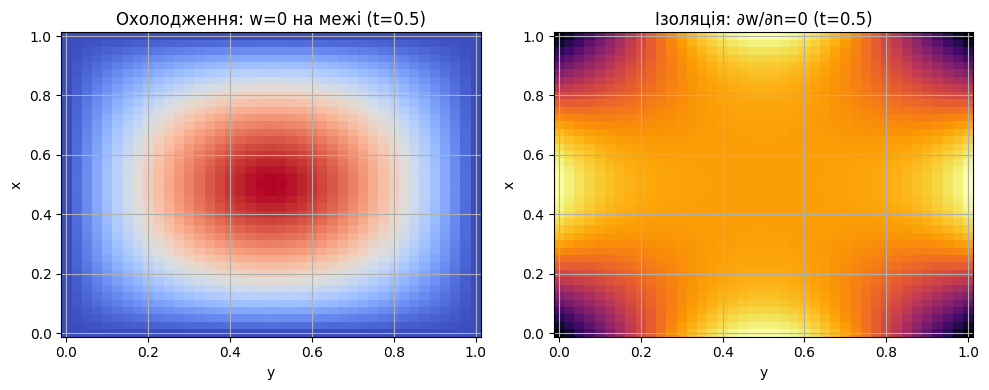

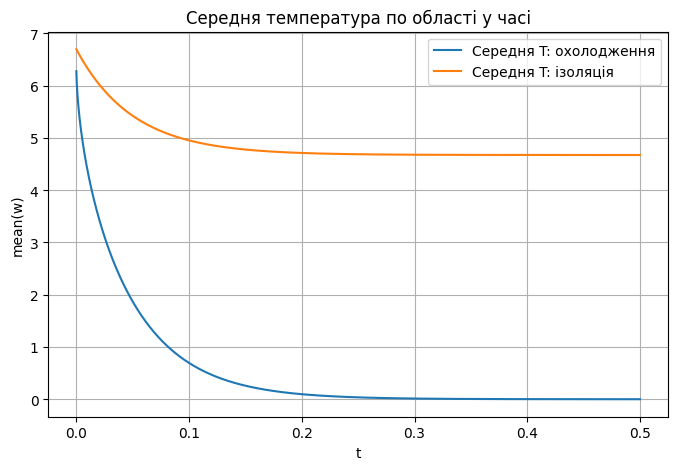

In [ ]:
def laplacian_2d_neumann(U, h):
    """Лапласіан з однорідними Neumann du/dn=0 (ghost: u_{-1}=u_{+1})."""
    nx, ny = U.shape
    Gi = np.empty((nx + 2, ny + 2))
    Gi[1:-1, 1:-1] = U
    Gi[0, 1:-1] = Gi[2, 1:-1]
    Gi[-1, 1:-1] = Gi[-3, 1:-1]
    Gi[1:-1, 0] = Gi[1:-1, 2]
    Gi[1:-1, -1] = Gi[1:-1, -3]
    Gi[0, 0] = Gi[2, 2]
    Gi[0, -1] = Gi[2, -3]
    Gi[-1, 0] = Gi[-3, 2]
    Gi[-1, -1] = Gi[-3, -3]
    Lap = np.zeros_like(U)
    # внутрішні вузли (i,j) = (1..nx-2, 1..ny-2) — 5-точковий стенсіл
    Lap[1:-1, 1:-1] = (
        (Gi[3 : nx + 1, 2:ny] - 2 * Gi[2:nx, 2:ny] + Gi[1 : nx - 1, 2:ny])
        + (Gi[2:nx, 3 : ny + 1] - 2 * Gi[2:nx, 2:ny] + Gi[2:nx, 1 : ny - 1])
    ) / (h * h)
    return Lap


def explicit_step_neumann(U, tau, h, t_n, X, Y, f_fn):
    """Явний крок з однорідними Neumann на межі (нульовий потік тепла)."""
    Un = U.copy()
    Lap = laplacian_2d_neumann(Un, h)
    F = f_fn(X, Y, t_n)
    Un[1:-1, 1:-1] += tau * (Lap[1:-1, 1:-1] + F[1:-1, 1:-1])
    return Un


def run_explicit_bc(bc_kind, T_end, tau):
    t = 0.0
    U = w_exact(X, Y, 0.0)
    if bc_kind == "dirichlet_zero":
        U[0, :] = U[-1, :] = U[:, 0] = U[:, -1] = 0.0
    means = [float(np.mean(U))]
    ts = [0.0]
    while t < T_end - 1e-15:
        dt = min(tau, T_end - t)
        if bc_kind == "dirichlet_zero":
            U = explicit_step(U, dt, h, t, X, Y, rhs_f_on_grid)
            U[0, :] = U[-1, :] = U[:, 0] = U[:, -1] = 0.0
        else:
            U = explicit_step_neumann(U, dt, h, t, X, Y, rhs_f_on_grid)
        t += dt
        ts.append(t)
        means.append(float(np.mean(U)))
    return U, ts, means


tau_demo = tau_explicit
U_cold, ts_c, mean_cold = run_explicit_bc("dirichlet_zero", 0.5, tau_demo)
U_iso, ts_i, mean_iso = run_explicit_bc("neumann", 0.5, tau_demo)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].pcolormesh(y, x, U_cold.T, shading="auto", cmap="coolwarm")
ax[0].set_title("Охолодження: w=0 на межі (t=0.5)")
ax[0].set_xlabel("y")
ax[0].set_ylabel("x")

ax[1].pcolormesh(y, x, U_iso.T, shading="auto", cmap="inferno")
ax[1].set_title("Ізоляція: ∂w/∂n=0 (t=0.5)")
ax[1].set_xlabel("y")
ax[1].set_ylabel("x")
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(ts_c, mean_cold, label="Середня T: охолодження")
plt.plot(ts_i, mean_iso, label="Середня T: ізоляція")
plt.xlabel("t")
plt.ylabel("mean(w)")
plt.legend()
plt.title("Середня температура по області у часі")
plt.show()


### Д.3 3D: тонка пластина

Співвідношення сторін як тонка пластина (довжина і ширина набагато більші за товщину). Квадратний нагрівач на задній грані по нормалі до товщини (координата в коді як у комірці). На задній і бічних гранях — умова Неймана; спереду — Робен (конвекція до повітря); поле **w** — надлишок відносно кімнатної температури.

Чисельно — явна семиточкова схема; крок по часу дрібний через обмеження стійкості по найменшому просторовому кроку. Деталі — у звіті.


In [20]:
# --- 3D: тонка пластина з нагрівачем позаду ---
Lx3 = 1.0
Ly3 = 1.0
Lz3 = 1.0 / 50.0

Nx3 = 30
Ny3 = 30
Nz3 = 6
hx3 = Lx3 / Nx3
hy3 = Ly3 / Ny3
hz3 = Lz3 / Nz3

x3 = np.linspace(0.0, Lx3, Nx3 + 1)
y3 = np.linspace(0.0, Ly3, Ny3 + 1)
z3 = np.linspace(0.0, Lz3, Nz3 + 1)
X3, Y3, Z3 = np.meshgrid(x3, y3, z3, indexing="ij")

# Нагрівач: квадратний рівномірний на задній стороні z=0
# Відступ 1 см від країв при пластині 30x30 см => частка 1/30 від розміру по x,y
margin_frac = 1.0 / 30.0
Q_src = 12000.0  # інтенсивність нагрівача (безрозмірно)
heater_thickness = Lz3 / 6.0  # невелика товщина джерела біля z=0
mask_xy = (
    (X3 >= margin_frac * Lx3) & (X3 <= (1.0 - margin_frac) * Lx3) &
    (Y3 >= margin_frac * Ly3) & (Y3 <= (1.0 - margin_frac) * Ly3)
)
mask_z = Z3 <= heater_thickness
F3 = Q_src * (mask_xy & mask_z).astype(float)


# Число Біо для переду: h*ell3/k (безрозмірно); більше — сильніша конвекція (поверхня ближче до Т_повітря)
BIOT_FRONT = 0.35


def laplacian_3d_mixed_bc(U, hx, hy, hz, Lz_plate, biot_front):
    # ghost: Нейман на z=0, x, y; на z=Lz — Робен ∂w/∂z + (biot/Lz) w = 0 (w — надлишок відносно кімнати).
    nx, ny, nz_ = U.shape
    G = np.empty((nx + 2, ny + 2, nz_ + 2))
    G[1:-1, 1:-1, 1:-1] = U
    G[0, 1:-1, 1:-1] = G[2, 1:-1, 1:-1]
    G[-1, 1:-1, 1:-1] = G[-3, 1:-1, 1:-1]
    G[1:-1, 0, 1:-1] = G[1:-1, 2, 1:-1]
    G[1:-1, -1, 1:-1] = G[1:-1, -3, 1:-1]
    G[1:-1, 1:-1, 0] = G[1:-1, 1:-1, 2]
    G[1:-1, 1:-1, -1] = G[1:-1, 1:-1, -3] - 2.0 * hz * (biot_front / Lz_plate) * G[1:-1, 1:-1, -2]
    L = (
        (G[2:, 1:-1, 1:-1] - 2 * G[1:-1, 1:-1, 1:-1] + G[:-2, 1:-1, 1:-1]) / (hx * hx)
        + (G[1:-1, 2:, 1:-1] - 2 * G[1:-1, 1:-1, 1:-1] + G[1:-1, :-2, 1:-1]) / (hy * hy)
        + (G[1:-1, 1:-1, 2:] - 2 * G[1:-1, 1:-1, 1:-1] + G[1:-1, 1:-1, :-2]) / (hz * hz)
    )
    return L


tau3_max = 1.0 / (2.0 * a * (1.0 / hx3 ** 2 + 1.0 / hy3 ** 2 + 1.0 / hz3 ** 2))
tau3 = 0.4 * tau3_max
T3 = 0.01
nsteps3 = int(np.ceil(T3 / tau3))
print(f"3D: tau_max={tau3_max:.3e}, tau={tau3:.3e}, steps={nsteps3}")

U3 = np.zeros_like(X3)  # надлишок температури відносно кімнати (Т_кімн = 0 у цій шкалі)

snap_frames = [0, nsteps3 // 4, nsteps3 // 2, 3 * nsteps3 // 4, nsteps3]
snap_times = [0.0]
snaps = [U3.copy()]

t3 = 0.0
for step in range(1, nsteps3 + 1):
    dt = min(tau3, T3 - t3)
    Lap = laplacian_3d_mixed_bc(U3, hx3, hy3, hz3, Lz3, BIOT_FRONT)
    U3 = U3 + dt * (Lap + F3)
    t3 += dt
    if step in snap_frames:
        snaps.append(U3.copy())
        snap_times.append(t3)

print(
    f"3D: max w = {U3.max():.4e}, max w на передній грані z=Lz = {U3[:, :, -1].max():.4e} "
    f"(>0 означає тепліше за повітря)"
)


3D: tau_max=5.447e-06, tau=2.179e-06, steps=4590
3D: max w = 4.4935e+00, max w на передній грані z=Lz = 3.4271e+00 (>0 означає тепліше за повітря)


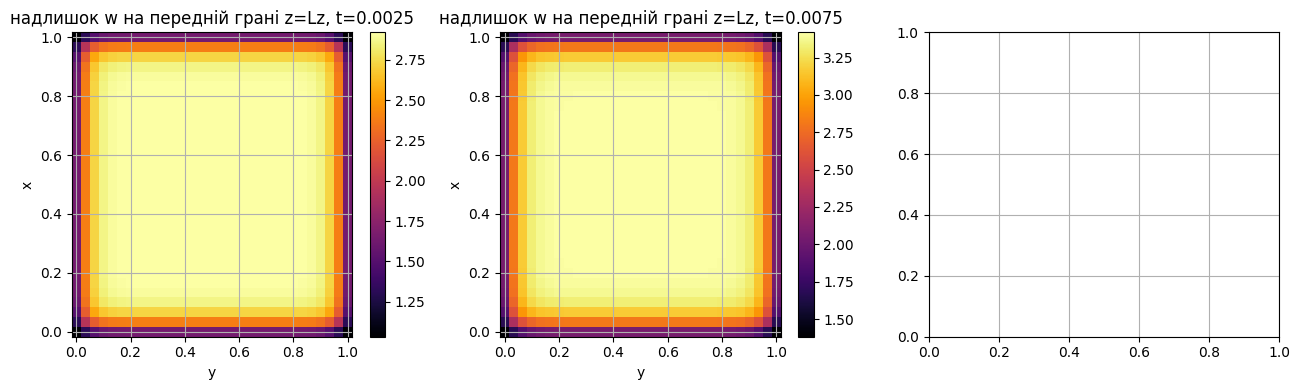

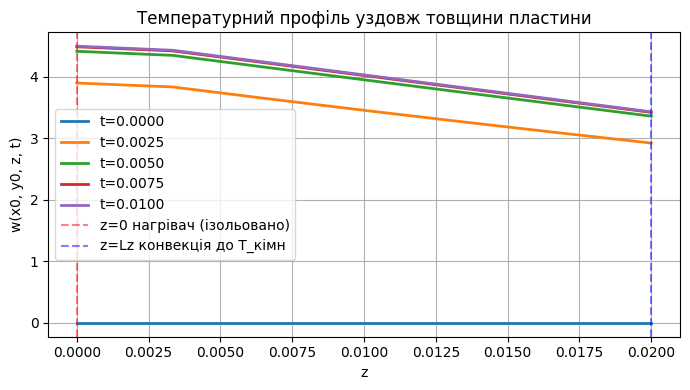

In [21]:
# Статичні matplotlib-візуалізації (heatmap на передній грані, розріз, профіль по z)
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax_i, tv, Uk in zip(axes, snap_times[1::2][:3], snaps[1::2][:3]):
    pcm = ax_i.pcolormesh(y3, x3, Uk[:, :, -1].T, shading="auto", cmap="inferno")
    ax_i.set_xlabel("y")
    ax_i.set_ylabel("x")
    ax_i.set_title(f"надлишок w на передній грані z=Lz, t={tv:.4f}")
    fig.colorbar(pcm, ax=ax_i)
fig.tight_layout()
plt.show()

# Профіль уздовж z через центр нагрівача
fig, ax = plt.subplots(figsize=(7, 4))
i0 = Nx3 // 2
j0 = Ny3 // 2
for Uk, tv in zip(snaps, snap_times):
    ax.plot(z3, Uk[i0, j0, :], label=f"t={tv:.4f}", lw=2)
ax.axvline(0, color="red", ls="--", alpha=0.5, label="z=0 нагрівач (ізольовано)")
ax.axvline(Lz3, color="blue", ls="--", alpha=0.5, label="z=Lz конвекція до Т_кімн")
ax.set_xlabel("z")
ax.set_ylabel("w(x0, y0, z, t)")
ax.set_title("Температурний профіль уздовж товщини пластини")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


#### Опційно: параметр потужності та час

Нижче — розрахунок для змінних керування потужністю та часом і простий автопідбір. Для інтерактиву зручніші слайдери в наступному блоці.


Пряме керування (задано чисельно):
                 Q: 1.200000e+03
                 T: 1.000000e-02
        front_mean: 3.125220e-01
         front_std: 4.778576e-02
         front_min: 1.388919e-01
         front_max: 3.427134e-01
  uniformity_index: 8.470963e-01


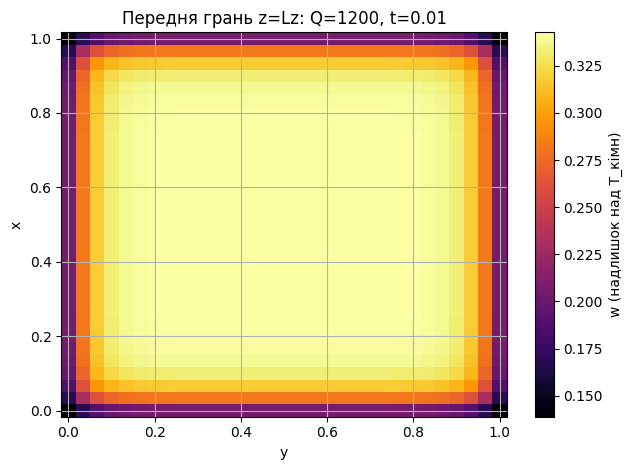

KeyboardInterrupt: 

In [22]:
# --- Числове керування Q і часу (без слайдерів) ---
def run_3d_case(Q_case, T_case, biot_front=BIOT_FRONT):
    F_case = Q_case * (mask_xy & mask_z).astype(float)
    U_case = np.zeros_like(X3)
    t_case = 0.0
    while t_case < T_case - 1e-15:
        dt = min(tau3, T_case - t_case)
        Lap = laplacian_3d_mixed_bc(U_case, hx3, hy3, hz3, Lz3, biot_front)
        U_case = U_case + dt * (Lap + F_case)
        t_case += dt

    front = U_case[:, :, -1]
    m_front = float(np.mean(front))
    s_front = float(np.std(front))
    mx_front = float(np.max(front))
    mn_front = float(np.min(front))
    uniformity = 1.0 - (s_front / (abs(m_front) + 1e-12))  # 1 = ідеально рівномірно
    return U_case, {
        "Q": float(Q_case),
        "T": float(T_case),
        "front_mean": m_front,
        "front_std": s_front,
        "front_min": mn_front,
        "front_max": mx_front,
        "uniformity_index": float(uniformity),
    }


# Режим 1: пряме керування
Q_ctrl = 1200.0
T_ctrl = 0.01

U_ctrl, stats_ctrl = run_3d_case(Q_ctrl, T_ctrl, biot_front=BIOT_FRONT)
print("Пряме керування (задано чисельно):")
for k, v in stats_ctrl.items():
    print(f"  {k:>16s}: {v:.6e}" if isinstance(v, float) else f"  {k}: {v}")

fig, ax = plt.subplots(figsize=(6.5, 4.8))
pcm = ax.pcolormesh(y3, x3, U_ctrl[:, :, -1].T, shading="auto", cmap="inferno")
ax.set_xlabel("y")
ax.set_ylabel("x")
ax.set_title(f"Передня грань z=Lz: Q={Q_ctrl:.0f}, t={T_ctrl}")
fig.colorbar(pcm, ax=ax, label="w (надлишок над T_кімн)")
fig.tight_layout()
plt.show()


# Режим 2: автопідбір Q і T під ціль
target_front_mean = 0.22   # бажане середнє на передній грані
target_uniformity = 0.85   # бажана рівномірність (ближче до 1 — краще)

Q_grid = np.linspace(600.0, 3000.0, 9)
T_grid = np.linspace(0.004, 0.03, 8)

best = None
best_score = 1e99
for Q_try in Q_grid:
    for T_try in T_grid:
        _, st = run_3d_case(Q_try, T_try, biot_front=BIOT_FRONT)
        score = (
            ((st["front_mean"] - target_front_mean) / (target_front_mean + 1e-12)) ** 2
            + ((st["uniformity_index"] - target_uniformity) / (target_uniformity + 1e-12)) ** 2
        )
        if score < best_score:
            best_score = score
            best = st

print("\nАвтопідбір (по сітці Q x T):")
print(f"  target front_mean = {target_front_mean:.6e}")
print(f"  target uniformity = {target_uniformity:.6e}")
print(f"  best score        = {best_score:.6e}")
for k in ["Q", "T", "front_mean", "front_std", "front_min", "front_max", "uniformity_index"]:
    print(f"  best {k:>11s} = {best[k]:.6e}")


Два слайдери: поточний час і потужність нагрівача (той самий параметр, що в коді для сили джерела).


In [ ]:
# Plotly + ipywidgets: одночасне керування часом і потужністю
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display

Z_SCALE = 15.0
z_vis = z3 * Z_SCALE
Lz_vis = Lz3 * Z_SCALE


def make_surfaces(U, vmax):
    kwargs = dict(
        colorscale="Turbo", cmin=0.0, cmax=vmax, showscale=False,
        lighting=dict(ambient=1.0, diffuse=0.35, specular=0.05),
    )
    traces = []
    Z0 = np.zeros_like(X3[:, :, 0])
    traces.append(go.Surface(x=X3[:, :, 0], y=Y3[:, :, 0], z=Z0,
                             surfacecolor=U[:, :, 0], **kwargs, name="Задня z=0"))
    Zf = np.full_like(X3[:, :, 0], Lz_vis)
    traces.append(go.Surface(x=X3[:, :, 0], y=Y3[:, :, 0], z=Zf,
                             surfacecolor=U[:, :, -1], **kwargs, name="Передня z=Lz"))
    Yl, Zl = np.meshgrid(y3, z_vis, indexing="ij")
    traces.append(go.Surface(x=np.zeros_like(Yl), y=Yl, z=Zl,
                             surfacecolor=U[0, :, :], **kwargs, name="x=0"))
    traces.append(go.Surface(x=np.full_like(Yl, Lx3), y=Yl, z=Zl,
                             surfacecolor=U[-1, :, :], **kwargs, name="x=Lx"))
    Xbw, Zbw = np.meshgrid(x3, z_vis, indexing="ij")
    traces.append(go.Surface(x=Xbw, y=np.zeros_like(Xbw), z=Zbw,
                             surfacecolor=U[:, 0, :], **kwargs, name="y=0"))
    traces.append(go.Surface(x=Xbw, y=np.full_like(Xbw, Ly3), z=Zbw,
                             surfacecolor=U[:, -1, :], **kwargs, name="y=Ly"))
    return traces


# Базові дані по часу беремо зі snaps (це розв'язок для Q_src)
U_time = list(snaps)
t_time = list(snap_times)
vmax_global = float(max(u.max() for u in U_time) * (3000.0 / Q_src) * 1.02)

q_slider = widgets.FloatSlider(
    value=float(Q_src), min=300.0, max=3000.0, step=100.0, description="w(Q):",
    continuous_update=False, readout_format=".0f",
)
t_slider = widgets.FloatSlider(
    value=float(t_time[-1]), min=float(t_time[0]), max=float(t_time[-1]),
    step=float((t_time[-1] - t_time[0]) / max(1, len(t_time) - 1)),
    description="t:", continuous_update=False, readout_format=".4f",
)


def pick_time_snapshot(t_val):
    idx = int(np.argmin(np.abs(np.array(t_time) - t_val)))
    return idx, U_time[idx], t_time[idx]


def redraw(q_val, t_val):
    idx, U_base, t_snap = pick_time_snapshot(t_val)
    U = U_base * (q_val / Q_src)  # лінійне масштабування по потужності джерела
    fig = go.Figure(data=make_surfaces(U, vmax_global))
    fig.add_trace(go.Surface(
        x=[[0]], y=[[0]], z=[[0]], surfacecolor=[[0]], colorscale="Turbo",
        cmin=0.0, cmax=vmax_global, showscale=True,
        colorbar=dict(title="w", thickness=18, len=0.7, x=1.02),
        opacity=0.0, showlegend=False, name="cb"
    ))
    fig.update_layout(
        title=f"3D: square_back_heater (відступ 1 см від країв) | t≈{t_snap:.4f}, w(Q)={q_val:.0f}",
        scene=dict(
            xaxis=dict(title="x", range=[0, Lx3]),
            yaxis=dict(title="y", range=[0, Ly3]),
            zaxis=dict(title=f"z (×{Z_SCALE:.0f})", range=[0, Lz_vis]),
            aspectratio=dict(x=1, y=1, z=0.35),
            camera=dict(eye=dict(x=1.35, y=-0.55, z=0.45), center=dict(x=0.45, y=0.45, z=0.12)),
        ),
        width=950, height=620, margin=dict(l=10, r=10, t=60, b=10),
    )
    fig.show()


ui = widgets.HBox([t_slider, q_slider])
out = widgets.interactive_output(redraw, {"q_val": q_slider, "t_val": t_slider})
display(ui, out)


Output()

### Д.4 Чорне тіло на передній грані: закон Стефана–Больцмана / Планка

Замість конвекції Ньютона можна знімати тепло з передньої грані `z=Lz` радіацією. Поверхневу температуру беремо як `T_surf = T_amb + T_scale * w` (поле `w` — безрозмірний надлишок), а потік — за законом Стефана–Больцмана: `q = ε σ (T_surf^4 − T_amb^4)`. У безрозмірних змінних це дає граничну умову

`−∂w/∂z = ε · rad_coef · ((T_surf/T_amb)^4 − 1)` на `z=Lz`,

де коефіцієнт `rad_coef` поглинає матеріальні константи (`σ`, `k_th`, `Lz_phys/T_scale`). Регульовані параметри: `ε` (0..1 — ступінь «чорноти»), `T_amb` (К), `T_scale` (К на одиницю `w`), `rad_coef` (сила радіативного зв’язку), `Q` (потужність нагрівача), `T_end` (час моделювання).

Окремо побудовано **спектральну випромінювальну здатність Планка** `B(λ, T)` для трьох температур: `T_amb`, середньої та максимальної на передній грані. Закон Віна (`λ_max · T = 2,898e−3 м·К`) визначає, у якому діапазоні «світить» поверхня.


In [ ]:
# --- Д.4 Чорне тіло: радіативна межа Стефана-Больцмана + спектр Планка ---
import ipywidgets as widgets
from IPython.display import display

SIGMA_SB = 5.670374419e-8        # Вт/(м²·К⁴)
H_PLANCK = 6.62607015e-34        # Дж·с
C_LIGHT  = 2.99792458e8          # м/с
K_BOLTZ  = 1.380649e-23          # Дж/К
WIEN_B   = 2.897771955e-3        # м·К — закон зміщення Віна


def planck_spectral_radiance(lam_m, T_K):
    """B(λ, T): спектральна яскравість чорного тіла, Вт/(м³·ср)."""
    lam = np.asarray(lam_m, dtype=float)
    x = (H_PLANCK * C_LIGHT) / (lam * K_BOLTZ * float(T_K))
    out = np.zeros_like(lam)
    safe = x < 700.0
    out[safe] = (2.0 * H_PLANCK * C_LIGHT ** 2 / lam[safe] ** 5) / np.expm1(x[safe])
    return out


def laplacian_3d_radiative_bc(U, hx, hy, hz, epsilon, T_amb_K, T_scale_K, rad_coef):
    """Той самий 7-точковий лапласіан, що і `laplacian_3d_mixed_bc`,
    але на передній грані z=Lz замість Робена — закон Стефана-Больцмана:
        −∂w/∂z = ε · rad_coef · ((T_surf/T_amb)^4 − 1),
        T_surf  = T_amb + T_scale · w.
    """
    nx, ny, nz_ = U.shape
    G = np.empty((nx + 2, ny + 2, nz_ + 2))
    G[1:-1, 1:-1, 1:-1] = U
    G[0, 1:-1, 1:-1]  = G[2, 1:-1, 1:-1]
    G[-1, 1:-1, 1:-1] = G[-3, 1:-1, 1:-1]
    G[1:-1, 0, 1:-1]  = G[1:-1, 2, 1:-1]
    G[1:-1, -1, 1:-1] = G[1:-1, -3, 1:-1]
    G[1:-1, 1:-1, 0]  = G[1:-1, 1:-1, 2]
    w_front = G[1:-1, 1:-1, -2]
    Tsurf   = T_amb_K + T_scale_K * w_front
    flux    = epsilon * rad_coef * ((Tsurf / T_amb_K) ** 4 - 1.0)
    G[1:-1, 1:-1, -1] = G[1:-1, 1:-1, -3] - 2.0 * hz * flux
    L = (
        (G[2:, 1:-1, 1:-1]  - 2 * G[1:-1, 1:-1, 1:-1] + G[:-2, 1:-1, 1:-1]) / (hx * hx)
        + (G[1:-1, 2:, 1:-1]  - 2 * G[1:-1, 1:-1, 1:-1] + G[1:-1, :-2, 1:-1]) / (hy * hy)
        + (G[1:-1, 1:-1, 2:]  - 2 * G[1:-1, 1:-1, 1:-1] + G[1:-1, 1:-1, :-2]) / (hz * hz)
    )
    return L


def run_3d_blackbody(epsilon, T_amb_K, T_scale_K, rad_coef, Q_case, T_end):
    F_case = Q_case * (mask_xy & mask_z).astype(float)
    U_case = np.zeros_like(X3)
    t_case = 0.0
    while t_case < T_end - 1e-15:
        dt = min(tau3, T_end - t_case)
        Lap = laplacian_3d_radiative_bc(U_case, hx3, hy3, hz3,
                                        epsilon, T_amb_K, T_scale_K, rad_coef)
        U_case = U_case + dt * (Lap + F_case)
        t_case += dt
    return U_case


def show_blackbody(epsilon, T_amb_K, T_scale_K, rad_coef, Q_case, T_end):
    U = run_3d_blackbody(epsilon, T_amb_K, T_scale_K, rad_coef, Q_case, T_end)
    w_front = U[:, :, -1]
    Tsurf   = T_amb_K + T_scale_K * w_front
    qrad    = epsilon * SIGMA_SB * (Tsurf ** 4 - T_amb_K ** 4)
    Tmin, Tmean, Tmax = float(Tsurf.min()), float(Tsurf.mean()), float(Tsurf.max())
    print(f"Передня грань (К):  min={Tmin:.2f}  mean={Tmean:.2f}  max={Tmax:.2f}")
    print(f"Радіативний потік:  mean={qrad.mean():.3e}  max={qrad.max():.3e}  Вт/м²")
    print(f"Закон Віна  λ_max:  T_amb→{WIEN_B/T_amb_K*1e6:.2f} мкм, "
          f"T_mean→{WIEN_B/Tmean*1e6:.2f} мкм, T_max→{WIEN_B/Tmax*1e6:.2f} мкм")

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
    pcm0 = axes[0].pcolormesh(y3, x3, Tsurf.T, shading="auto", cmap="inferno")
    axes[0].set_title("T поверхні z=Lz, К")
    axes[0].set_xlabel("y"); axes[0].set_ylabel("x")
    fig.colorbar(pcm0, ax=axes[0])

    pcm1 = axes[1].pcolormesh(y3, x3, qrad.T, shading="auto", cmap="viridis")
    axes[1].set_title("Радіативний потік q, Вт/м²")
    axes[1].set_xlabel("y"); axes[1].set_ylabel("x")
    fig.colorbar(pcm1, ax=axes[1])

    lam = np.linspace(0.3e-6, 30e-6, 600)  # 0,3..30 мкм
    for T_val, label, ls in [
        (T_amb_K, f"T_amb = {T_amb_K:.0f} К",   "--"),
        (Tmean,   f"T_mean = {Tmean:.0f} К",    "-"),
        (Tmax,    f"T_max = {Tmax:.0f} К",      "-"),
    ]:
        axes[2].plot(lam * 1e6, epsilon * planck_spectral_radiance(lam, T_val),
                     label=label, linestyle=ls)
    axes[2].set_xlabel("λ, мкм")
    axes[2].set_ylabel("ε · B(λ, T), Вт/(м³·ср)")
    axes[2].set_title("Спектр Планка (з ε)")
    axes[2].set_xscale("log"); axes[2].set_yscale("log")
    axes[2].grid(True, which="both", alpha=0.3)
    axes[2].legend(fontsize=8)
    fig.tight_layout()
    plt.show()


eps_w   = widgets.FloatSlider(value=0.9,    min=0.05, max=1.0,  step=0.05,
                              description="ε:",        continuous_update=False)
Tamb_w  = widgets.FloatSlider(value=293.15, min=200.0, max=400.0, step=5.0,
                              description="T_amb, К:",  continuous_update=False)
Tsc_w   = widgets.FloatSlider(value=200.0,  min=10.0,  max=1000.0, step=10.0,
                              description="T_scale, К:", continuous_update=False)
rcf_w   = widgets.FloatSlider(value=0.4,    min=0.0,   max=2.0,   step=0.05,
                              description="rad_coef:",  continuous_update=False)
Q_w     = widgets.FloatSlider(value=1200.0, min=200.0, max=4000.0, step=100.0,
                              description="Q:",         continuous_update=False)
Tend_w  = widgets.FloatSlider(value=0.01,   min=0.002, max=0.05,  step=0.002,
                              description="T_end:",     continuous_update=False, readout_format=".3f")

ui  = widgets.VBox([
    widgets.HBox([eps_w, Tamb_w, Tsc_w]),
    widgets.HBox([rcf_w, Q_w, Tend_w]),
])
out = widgets.interactive_output(show_blackbody, {
    "epsilon": eps_w, "T_amb_K": Tamb_w, "T_scale_K": Tsc_w,
    "rad_coef": rcf_w, "Q_case": Q_w, "T_end": Tend_w,
})
display(ui, out)